In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import pennylane as qml
from torchinfo import summary
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- DataLoader for Brain Tumor Dataset ---
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder('/content/drive/MyDrive/brain-tumor-data/Training', transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=2)
test_dataset = datasets.ImageFolder('/content/drive/MyDrive/brain-tumor-data/Testing', transform=transform) # Apply transform to test_dataset
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=True,num_workers=2)

cuda


In [ ]:
# --- Quantum Circuit (QNode) ---
dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AmplitudeEmbedding(inputs, wires=range(4), normalize=True)
    qml.BasicEntanglerLayers(weights, wires=range(4))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

n_layers = 1
weight_shapes = {"weights": (n_layers, 4)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# --- QuFeX Module ---
class QuFeX(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer
        self.unfold = nn.Unfold(kernel_size=2, stride=2)

    def forward(self, x):
        patches = self.unfold(x)
        patches = patches.transpose(1, 2)  # [B, num_patches, C*4]
        B, num_patches, dim = patches.shape
        patches = patches.reshape(B * num_patches, dim)
        q_out = self.qlayer(patches)  # [B*num_patches, 4]
        q_out = q_out.reshape(B, num_patches * 4)
        return q_out

In [ ]:
def train_model(model, train_loader, optimizer, criterion_cls, criterion_recon=None,
                num_epochs=5, mode="full",alpha=1.0):
    """
    mode:
        "full" — Y-Net with reconstruction (uses both MSE + CE losses)
        "classifier" — Only encoder + QuFeX + classifier (uses CE loss only)
    """
    recon_losses = []
    cls_losses = []

    model.train()
    for epoch in range(num_epochs):
        total_recon_loss = 0.0
        total_cls_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

        for imgs, labels in progress_bar:
            optimizer.zero_grad()
            imgs, labels = imgs.to(device), labels.to(device)

            if mode == "full":
                recon_out, cls_out = model(imgs)
                loss_recon = criterion_recon(recon_out, imgs)
                loss_cls = criterion_cls(cls_out, labels)
                loss = alpha*loss_recon + loss_cls
                total_recon_loss += loss_recon.item()
            elif mode == "classifier":
                _, cls_out = model(imgs)  # ignore recon output
                loss_cls = criterion_cls(cls_out, labels)
                loss = loss_cls
            else:
                raise ValueError("mode must be either 'full' or 'classifier'")

            loss.backward()
            optimizer.step()
            total_cls_loss += loss_cls.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_cls = total_cls_loss / len(train_loader)
        cls_losses.append(avg_cls)
        if mode == "full":
            avg_recon = total_recon_loss / len(train_loader)
            recon_losses.append(avg_recon)
            print(f"Epoch {epoch+1}: Recon Loss = {avg_recon:.4f}, Class Loss = {avg_cls:.4f}")
        else:
            print(f"Epoch {epoch+1}: Class Loss = {avg_cls:.4f}")

    return recon_losses if mode == "full" else None, cls_losses

In [ ]:
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc=f"Testing", unit="batch")
        for imgs, labels in progress_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            _, outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

In [ ]:
from sklearn.metrics import accuracy_score

def plot_results(recon_losses, cls_losses, preds, labels, class_names=None):
    # --- Loss Curve Plots ---
    if recon_losses is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(recon_losses, label='Reconstruction Loss (MSE)', color='tab:blue')
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.set_title("Reconstruction Loss (MSE)")
        ax1.legend()
        ax1.grid(True)

        ax2.plot(cls_losses, label='Classification Loss (CE)', color='tab:orange')
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")
        ax2.set_title("Classification Loss (CE)")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 4))
        plt.plot(cls_losses, label='Classification Loss (CE)', color='tab:orange')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Classification Loss (CE)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    acc = accuracy_score(labels, preds)
    print("accuracy: ",acc)
    # --- Confusion Matrix ---
    if len(preds) == 0 or len(labels) == 0:
        print("Confusion matrix cannot be plotted: empty predictions or labels.")
        return

    cm = confusion_matrix(labels, preds)
    if class_names is None:
        class_count = cm.shape[0]
        class_names = [f"Class {i}" for i in range(class_count)]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


Y-NET

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- DoubleConv Block (used in U-Net) ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

# --- U-Net Encoder ---
class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

    def forward(self, x):
        x1 = self.enc1(x)               # [B, 32, 64, 64]
        x2 = self.enc2(self.pool1(x1))  # [B, 64, 32, 32]
        x3 = self.enc3(self.pool2(x2))  # [B, 128, 16, 16]
        return x3, [x1, x2]

# --- U-Net Decoder ---
class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)  # output = reconstructed image

    def forward(self, x, enc_feats):
        x = self.up1(x)
        x = torch.cat([x, enc_feats[1]], dim=1)
        x = self.dec1(x)
        x = self.up2(x)
        x = torch.cat([x, enc_feats[0]], dim=1)
        x = self.dec2(x)
        return self.out_conv(x)

# --- Y-Net with QuFeX Bottleneck ---
class YNetAutoencoder(nn.Module):
    def __init__(self, mode="full"):
        super().__init__()
        self.mode = mode
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.bottleneck_to_qufex_channels = nn.Conv2d(128, 4, kernel_size=1)  # for 4-qubit AmplitudeEmbedding
        self.qufex = QuFeX()

        # self.classifier = nn.Sequential(
        #     nn.Linear(64, 64),  # 16 patches × 4 qubit outputs = 64
        #     nn.ReLU(),
        #     nn.Linear(64, 3)    # 3 classes for classification
        # )
        self.classifier = nn.Sequential(
             nn.Linear(256, 64),
             nn.Linear(64, 4)
        )

    def forward(self, x):
        bottleneck, skips = self.encoder(x)                          # [B, 128, 8, 8]
        qufex_input = self.bottleneck_to_qufex_channels(bottleneck) # [B, 4, 8, 8]
        q_features = self.qufex(qufex_input)                         # [B, 64]
        class_out = self.classifier(q_features)                      # [B, 3]
        recon_out = None
        if self.mode == "full":
            recon_out = self.decoder(bottleneck, skips)              # [B, 1, 64, 64]
        return recon_out, class_out

summary(YNetAutoencoder(), input_size=(16, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
YNetAutoencoder                          [16, 1, 64, 64]           --
├─UNetEncoder: 1-1                       [16, 128, 16, 16]         --
│    └─DoubleConv: 2-1                   [16, 32, 64, 64]          --
│    │    └─Sequential: 3-1              [16, 32, 64, 64]          9,568
│    └─MaxPool2d: 2-2                    [16, 32, 32, 32]          --
│    └─DoubleConv: 2-3                   [16, 64, 32, 32]          --
│    │    └─Sequential: 3-2              [16, 64, 32, 32]          55,424
│    └─MaxPool2d: 2-4                    [16, 64, 16, 16]          --
│    └─DoubleConv: 2-5                   [16, 128, 16, 16]         --
│    │    └─Sequential: 3-3              [16, 128, 16, 16]         221,440
├─Conv2d: 1-2                            [16, 4, 16, 16]           516
├─QuFeX: 1-3                             [16, 256]                 --
│    └─Unfold: 2-6                       [16, 16, 64]              --
│ 

Epoch 1/5: 100%|██████████| 350/350 [35:59<00:00,  6.17s/batch, loss=0.721]


Epoch 1: Recon Loss = 0.0035, Class Loss = 0.7766


Epoch 2/5: 100%|██████████| 350/350 [00:33<00:00, 10.48batch/s, loss=0.325]


Epoch 2: Recon Loss = 0.0006, Class Loss = 0.4342


Epoch 3/5: 100%|██████████| 350/350 [00:32<00:00, 10.68batch/s, loss=0.291]


Epoch 3: Recon Loss = 0.0004, Class Loss = 0.3463


Epoch 4/5: 100%|██████████| 350/350 [00:32<00:00, 10.69batch/s, loss=0.523]


Epoch 4: Recon Loss = 0.0003, Class Loss = 0.2779


Epoch 5/5: 100%|██████████| 350/350 [00:32<00:00, 10.81batch/s, loss=0.23]

Epoch 5: Recon Loss = 0.0003, Class Loss = 0.2110


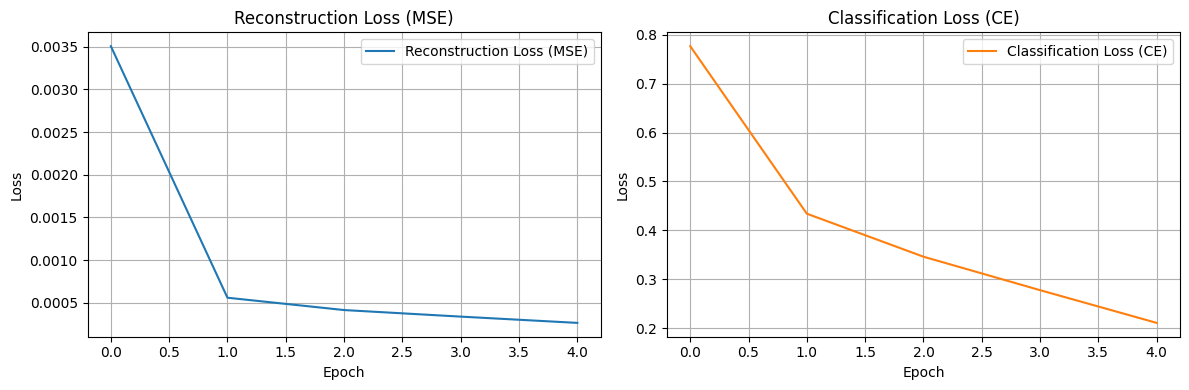

0.843125


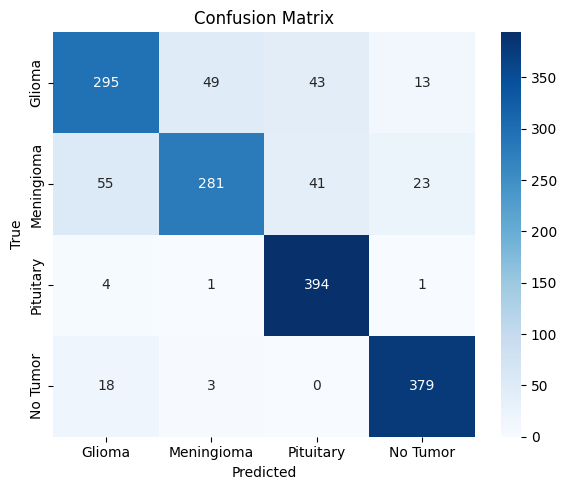

In [ ]:
model = YNetAutoencoder().to(device) # Move model to device
criterion_recon = nn.MSELoss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_recon, loss_cls = train_model(model, train_loader, optimizer=optimizer, criterion_cls=criterion_cls, criterion_recon=criterion_recon, num_epochs=5, mode="full")
all_preds, all_lab = test_model(model, test_loader)
plot_results(loss_recon, loss_cls, all_preds, all_lab, class_names=["Glioma", "Meningioma", "Pituitary", "No Tumor"])

Epoch 1/5: 100%|██████████| 350/350 [00:32<00:00, 10.70batch/s, loss=0.54]


Epoch 1: Class Loss = 0.7912


Epoch 2/5: 100%|██████████| 350/350 [00:33<00:00, 10.36batch/s, loss=0.443]


Epoch 2: Class Loss = 0.4678


Epoch 3/5: 100%|██████████| 350/350 [00:32<00:00, 10.83batch/s, loss=0.533]


...

Epoch 4/5: 100%|██████████| 350/350 [00:32<00:00, 10.62batch/s, loss=0.155]


Epoch 4: Class Loss = 0.2901


Epoch 5/5: 100%|██████████| 350/350 [00:33<00:00, 10.47batch/s, loss=0.405]


Epoch 5: Class Loss = 0.2297


Testing: 100%|██████████| 100/100 [00:07<00:00, 13.47batch/s]


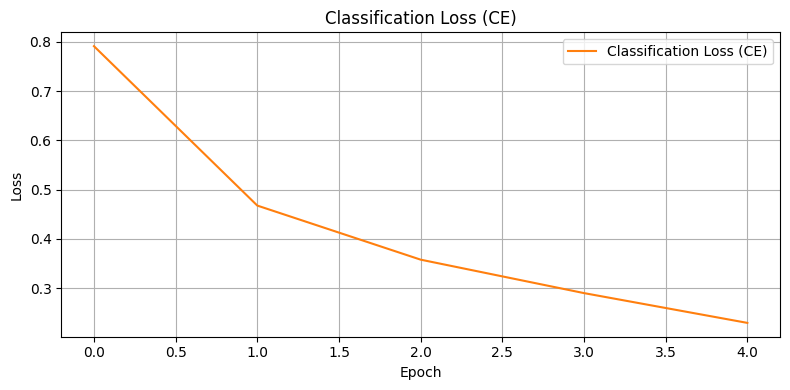

accuracy:  0.823125


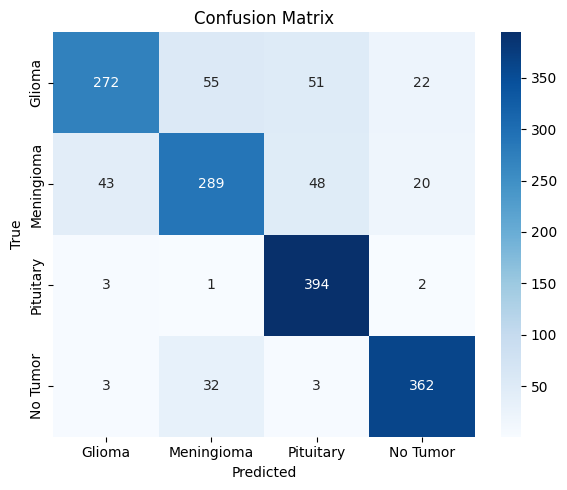

In [ ]:
model = YNetAutoencoder(mode="half").to(device) # Move model to device
criterion_recon = nn.MSELoss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_recon, loss_cls = train_model(model, train_loader, optimizer=optimizer, criterion_cls=criterion_cls, criterion_recon=criterion_recon, num_epochs=5, mode="classifier")
all_preds, all_lab = test_model(model, test_loader)
plot_results(loss_recon, loss_cls, all_preds, all_lab, class_names=["Glioma", "Meningioma", "Pituitary", "No Tumor"])

In [ ]:
train_model(model, train_loader, optimizer=optimizer, criterion_cls=criterion_cls, criterion_recon=criterion_recon, num_epochs=5, mode="full")

Epoch 1/5: 100%|██████████| 350/350 [12:47<00:00,  2.19s/batch, loss=0.419]


Epoch 1: Recon Loss = 0.0026, Class Loss = 0.7670


Epoch 2/5: 100%|██████████| 350/350 [00:31<00:00, 10.95batch/s, loss=0.718]


Epoch 2: Recon Loss = 0.0005, Class Loss = 0.4477


Epoch 3/5: 100%|██████████| 350/350 [00:31<00:00, 11.07batch/s, loss=0.177]


...

Epoch 4/5: 100%|██████████| 350/350 [00:31<00:00, 11.07batch/s, loss=0.153]


Epoch 4: Recon Loss = 0.0003, Class Loss = 0.2850


Epoch 5/5: 100%|██████████| 350/350 [00:31<00:00, 10.96batch/s, loss=0.228]

Epoch 5: Recon Loss = 0.0002, Class Loss = 0.2333


([0.0026481108182841648,
  0.0004944360313571192,
  0.0002969906681599761,
  0.0002567425892838011,
  0.00021017679566284642],
 [0.7670311648079328,
  0.44770956643990106,
  0.3639161302787917,
  0.2850422741366284,
  0.2333389428736908])

In [ ]:
loss_recon = [0.0026481108182841648,
  0.0004944360313571192,
  0.0002969906681599761,
  0.0002567425892838011,
  0.00021017679566284642]

loss_cls = [0.7670311648079328,
  0.44770956643990106,
  0.3639161302787917,
  0.2850422741366284,
  0.2333389428736908]

In [ ]:
all_preds, all_lab = test_model(model, test_loader)

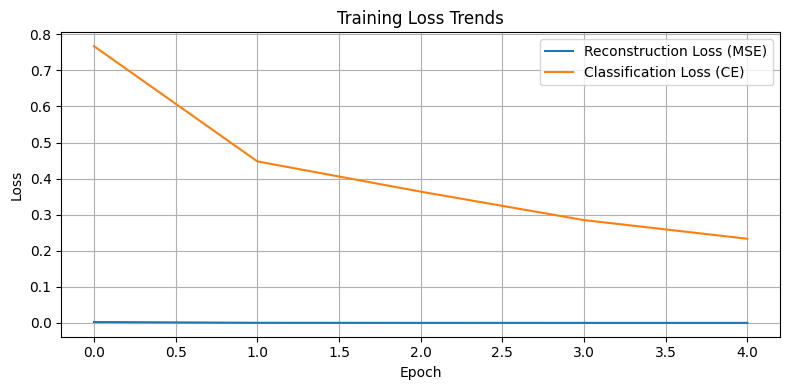

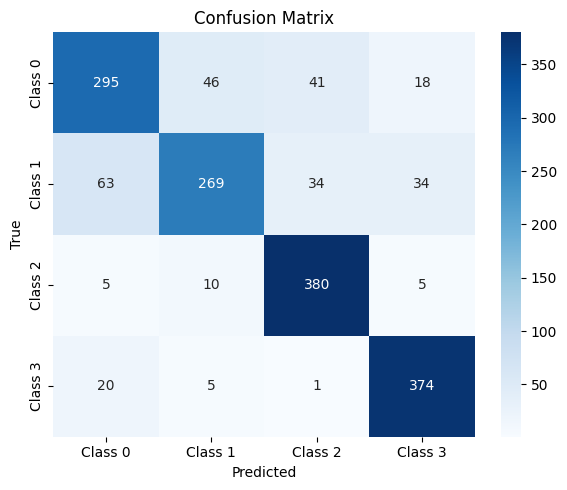

In [ ]:
plot_results(loss_recon, loss_cls, all_preds, all_lab, class_names=["Glioma", "Meningioma", "Pituitary", "No Tumor"])